In [ ]:
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "code").is_dir() and (path / "model").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project root containing code/ and model/")
DATA_DIR = PROJECT_ROOT / "code" / "data"
MODEL_DIR = PROJECT_ROOT / "model"
ASSET_DIR = PROJECT_ROOT / "src"



Finidgs

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              precision_score, recall_score,
                              confusion_matrix, classification_report,
                              RocCurveDisplay)

In [3]:
#loading data
df = pd.read_csv(DATA_DIR / "Edited_Data.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_0-1yr,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-5yr,tenure_group_5-6yr
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,True,False,True,False,False,False,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,True,False,False,True,False,False
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,True,True,False,False,False,False
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,True,False,False,False,False,False,True,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,True,False,True,False,False,False,False


In [4]:
# dropping target column
X = df.drop('Churn', axis = 1)
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 48)
Target shape: (7043,)


In [5]:
#Train Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # using stratified sampling to preserve the original churn-class distribution
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test target distribution:\n", y_test.value_counts(normalize=True).round(3))

Train size: (5634, 48)
Test size: (1409, 48)

Train target distribution:
 Churn
0    0.735
1    0.265
Name: proportion, dtype: float64
Test target distribution:
 Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [6]:
# scaling features 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#training models: Logistic Regression, Decision Tree, Random Forest, KNN and XGBoost

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'XGBoost':             XGBClassifier(use_label_encoder=False,
                                         eval_metric='logloss',
                                         random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, preds), 3),
        'ROC-AUC':   round(roc_auc_score(y_test, probs), 3),
        'F1-Score':  round(f1_score(y_test, preds), 3),
        'Precision': round(precision_score(y_test, preds), 3),
        'Recall':    round(recall_score(y_test, preds), 3)
    }

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(results_df)

/Users/nilakshiroy/Customer Retention Intelligence/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [15:16:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                     Accuracy  ROC-AUC  F1-Score  Precision  Recall
Logistic Regression     0.808    0.847     0.598      0.674   0.537
XGBoost                 0.781    0.827     0.558      0.600   0.521
Random Forest           0.789    0.820     0.559      0.626   0.505
KNN                     0.760    0.776     0.536      0.551   0.521
Decision Tree           0.719    0.651     0.488      0.472   0.505


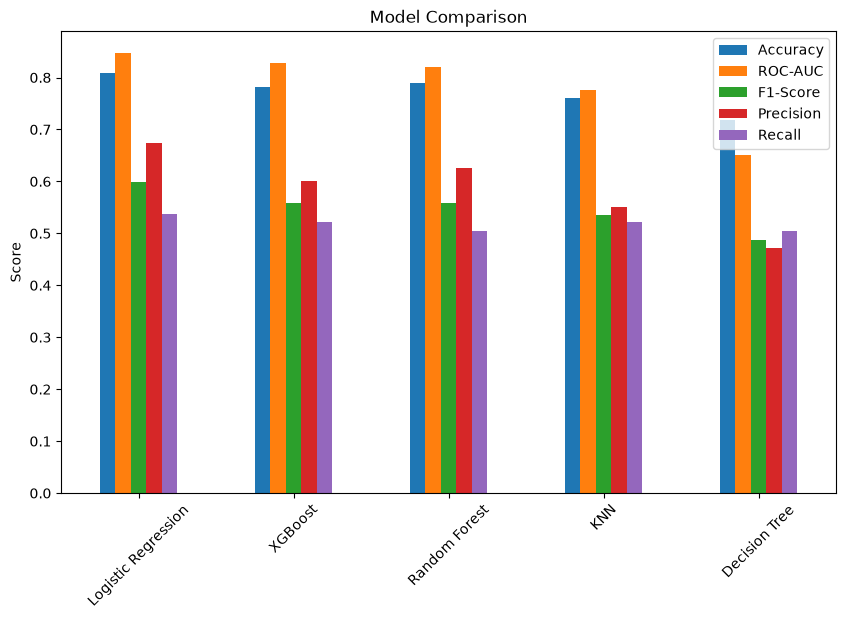

In [8]:
# Visualize Model Comparison


results_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.show()

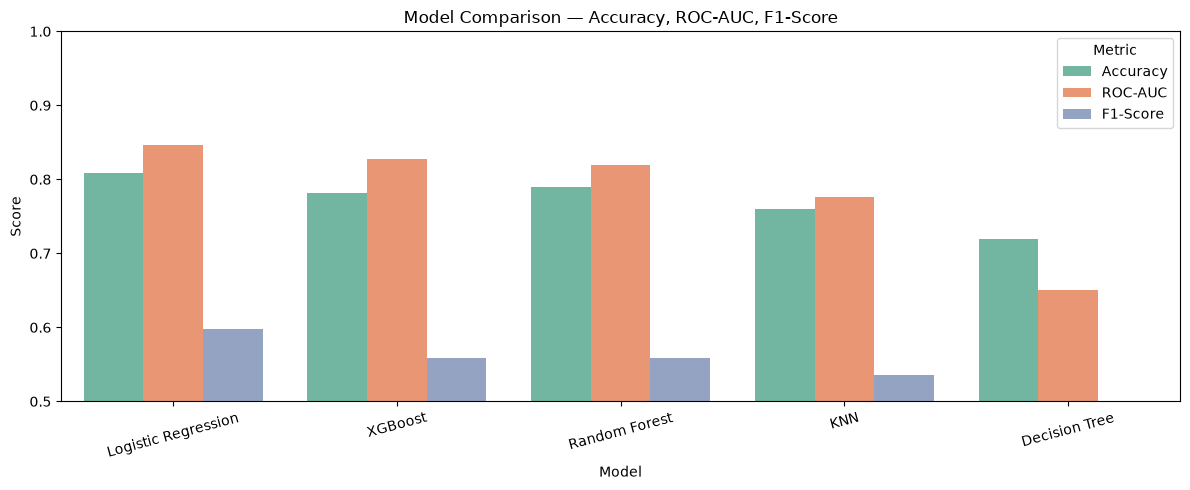

In [9]:
# or

results_df_plot = results_df[['Accuracy', 'ROC-AUC', 'F1-Score']].reset_index()
results_df_melted = results_df_plot.melt(id_vars='index',
                                          var_name='Metric',
                                          value_name='Score')

plt.figure(figsize=(12, 5))
sns.barplot(data=results_df_melted, x='index', y='Score',
            hue='Metric', palette='Set2')
plt.title('Model Comparison — Accuracy, ROC-AUC, F1-Score')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(ASSET_DIR / "model_comparison.png", dpi=150)
plt.show()

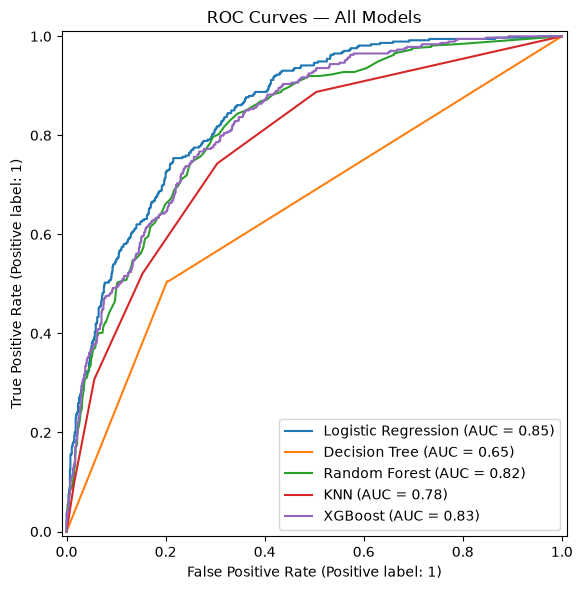

In [10]:
# ROC Curves for All Models

fig, ax = plt.subplots(figsize=(10, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test,
                                   ax=ax, name=name)

ax.set_title('ROC Curves — All Models')
plt.tight_layout()
plt.savefig(ASSET_DIR / "roc_curves.png", dpi=150)
plt.show()

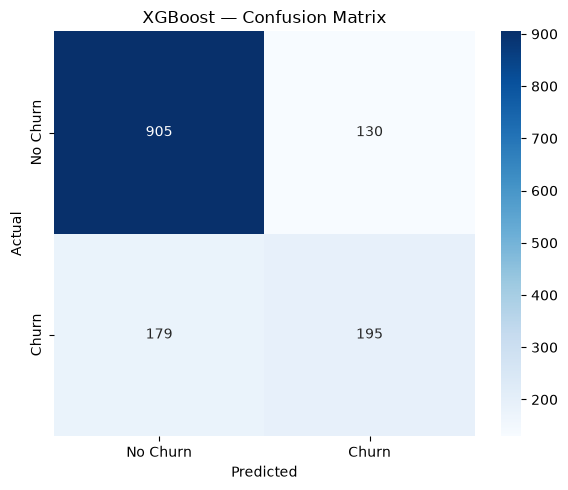


Classification Report — XGBoost:
              precision    recall  f1-score   support

    No Churn       0.83      0.87      0.85      1035
       Churn       0.60      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409



In [11]:
# Confusion matrix for XGBoost model

best_model = models['XGBoost']
preds_xgb = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, preds_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(ASSET_DIR / "confusion_matrix_xgb.png", dpi=150)
plt.show()

print("\nClassification Report — XGBoost:")
print(classification_report(y_test, preds_xgb,
      target_names=['No Churn', 'Churn']))




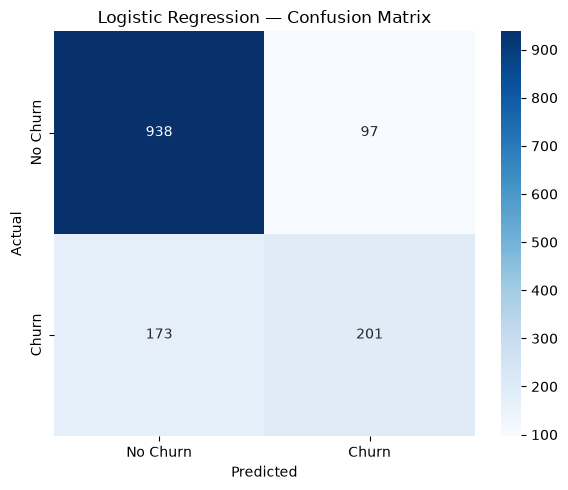


Classification Report — Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [12]:
# Confusion matrix for Logistic Regression model

best_model = models['Logistic Regression']
preds_lr = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, preds_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(ASSET_DIR / "confusion_matrix_lr.png", dpi=150)
plt.show()

print("\nClassification Report — Logistic Regression:")
print(classification_report(y_test, preds_lr,
      target_names=['No Churn', 'Churn']))

In [13]:
# Hyperparameter tuning for the logistic regression model with GridSearchCV

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

grid_search_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search_lr.fit(X_train_scaled, y_train)
print("Best Parameters:")
print(grid_search_lr.best_params_)

print("\nBest CV F1 Score:")
print(grid_search_lr.best_score_)

Best Parameters:
{'C': 0.01, 'class_weight': 'balanced', 'solver': 'lbfgs'}

Best CV F1 Score:
0.6351448334627477


In [14]:
# Evaluate the best logistic regression model on the test set
best_lr = grid_search_lr.best_estimator_

preds_lr = best_lr.predict(X_test_scaled)
probs_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

print("Classification Report — Tuned Logistic Regression:")
print(
    classification_report(
        y_test,
        preds_lr,
        target_names=['No Churn', 'Churn']
    )
)

print("ROC-AUC:", round(roc_auc_score(y_test, probs_lr), 3))
print("Confusion Matrix:")
print(f"  Accuracy:  {accuracy_score(y_test, preds_lr):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, probs_lr):.3f}")
print(f"  F1-Score:  {f1_score(y_test, preds_lr):.3f}")
print(f"  Precision: {precision_score(y_test, preds_lr):.3f}")
print(f"  Recall:    {recall_score(y_test, preds_lr):.3f}")

Classification Report — Tuned Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.848
Confusion Matrix:
  Accuracy:  0.740
  ROC-AUC:   0.848
  F1-Score:  0.616
  Precision: 0.506
  Recall:    0.786


In [15]:
# Hyperparameter tuning for the Xgboost regression model with GridSearchCV
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

xgb_tuned = XGBClassifier(use_label_encoder=False,
                            eval_metric='logloss',
                            random_state=42)

grid_search = GridSearchCV(
    xgb_tuned,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=1,        # ← Changed from -1 to 1 (fixes Windows multiprocessing issue)
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 3))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/nilakshiroy/Customer Retention Intelligence/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [15:16:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nilakshiroy/Customer Retention Intelligence/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [15:16:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nilakshiroy/Customer Retention Intelligence/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [15:16:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nilakshiroy/Customer Retention Intelligence/.venv/lib/python3.14/site-packages/xgboost/training.py:200: User

Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV ROC-AUC: 0.849


/Users/nilakshiroy/Customer Retention Intelligence/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [15:17:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
# Evaluate the tuned XGBoost model on the test set

best_xgb = grid_search.best_estimator_

preds_tuned = best_xgb.predict(X_test_scaled)
probs_tuned = best_xgb.predict_proba(X_test_scaled)[:, 1]

print("Tuned XGBoost Results:")
print(f"  Accuracy:  {accuracy_score(y_test, preds_tuned):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, probs_tuned):.3f}")
print(f"  F1-Score:  {f1_score(y_test, preds_tuned):.3f}")
print(f"  Precision: {precision_score(y_test, preds_tuned):.3f}")
print(f"  Recall:    {recall_score(y_test, preds_tuned):.3f}")

Tuned XGBoost Results:
  Accuracy:  0.808
  ROC-AUC:   0.848
  F1-Score:  0.588
  Precision: 0.682
  Recall:    0.516


In [17]:
# Save the best model
import joblib
joblib.dump(best_xgb, MODEL_DIR / "xgb_best_model.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(list(X.columns), MODEL_DIR / "feature_names.pkl")


['feature_names.pkl']